<a href="https://colab.research.google.com/github/brenoigo-ai/Sistema_de_Controle_Pessoal_de_Estudos/blob/main/Sistema_de_Controle_Pessoal_de_Estudos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

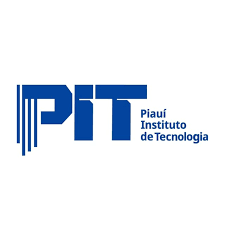

# FACULDADE ESTADUAL PIAUÍ INSTITUTO DE TECNOLOGIA - PIT

BACHARELADO EM INTELIGÊNCIA ARTIFICIAL - 1º PERÍODO

PROFESSORA EVELYN KARINNE SILVA

DISCIPLINA: ALGORITMOS E PROGRAMAÇÃO

ALUNOS:

**BRENO IGO BORGES PEREIRA DE ARAÚJO**

**LUIZ HENRIQUE SOUSA E SILVA**

**RAIMUNDO CLECIO DANTAS MUNIZ FILHO**

---

**DESAFIO PRÁTICO UTILIZANDO CRUD COM DICIONÁRIO E ARQUIVOS NO PYTHON**

O presente trabalho tem como objetivo aplicar os conhecimentos práticos e teóricos adquiridos na disciplina de Algoritmos e Programação, do 1º período do Curso de Bacharelado em Inteligência Artificial da Faculdade Estadual Piauí Instituto de Tecnologia - PIT. A finalidade central consiste em criar um sistema em linguagem Python que gerencia algo, estruturado em torno do CRUD (Create, Read, Update, Delete) e utilizando Dicionários e manipulação de arquivos locais.

No caso em tela, trata-se de um Sistema de Controle Pessoal de Estudos e Resolução de Questões. A escolha deve-se à necessidade de organização, disciplina e autorregulação para estudos de alto rendimento, em especial, para aqueles que almejam concursos públicos, vestibulares concorridos e até para nós, estudantes universitários da área da tecnologia. Desse modo, o sistema criado permite que o usuário identifique ativamente seu esforço, evidencia o tempo investido em cada discplina e, o mais importante, monitora sua taxa de acertos em exercícios práticos de modo a identificar por meio dos dados quais matérias domina, bem como aquelas que precisam de mais atenção, otimizando seu tempo e melhorando seu desempenho.

O sistema utiliza uma Lista de Dicionários e a biblioteca nativa JSON. Foi criado funções que abrem o arquivo no modo `'r'` (leitura) ao iniciar o programa, convertendo o texto em dicionários (via `json.load`). Ao final de qualquer alteração, o arquivo é reescrito no modo `'w'` (escrita) salvando a lista atualizada (via `json.dump`).
* Em relação ao **C.R.U.D:**
  * **C (Create):** Função `criar_sessao()`. Coleta dados através de funções de validação que impedem strings vazias ou números absurdos. Gera um ID automaticamente e calcula a taxa de acerto antes de fazer o `.append()` na lista.
  * **R (Read):** Função `listar_sessoes()`. Utiliza um laço `for` para percorrer a lista de dicionários e exibe o histórico formatado. Trata listas vazias com o operador lógico `not`.
  * **U (Update):** Função `atualizar_sessao()`. Busca uma sessão pelo ID. Permite que o usuário pressione apenas `ENTER` para manter o dado antigo intacto (usando lógicas de `OR` e checagem de strings vazias).
  * **D (Delete):** Função `excluir_sessao()`. Localiza o índice do dicionário usando `enumerate` e, após confirmação de segurança, remove o registro da memória utilizando o método `.pop()`.
  * **Dashboard Visual:** Função `gerar_dashboard()`. Agrupa os dados processados utilizando lógica de laços `for` e dicionários auxiliares, enviando as médias matemáticas para a biblioteca `matplotlib` desenhar os gráficos.

Portanto, conta com salvamento automático de dados no disco rígido através de arquivos JSON, garantindo que o histórico não seja perdido ao fechar o programa. Indo além, foi implementado um Painel Analítico (Dashboard) utilizando a biblioteca matplotlib, que traduz os dados armazenados na lista de dicionários em gráficos visuais dinâmicos, bem como a taxa média de acertos e o tempo total dedicado a cada disciplina. Assim transforma o estudo através de um processo guiado por dados.

Durante o desenvolvimento do código, as dificuldades encontradas foram:

1. **O Bug da Divisão por Zero:** Na regra de negócio do CREATE, percebemos que se o usuário apenas lesse um PDF e não fizesse questões (0 questões), o cálculo da taxa de acerto (`acertos / questoes`) causaria um erro fatal (`ZeroDivisionError`). Solucionamos adicionando um `if` de proteção na função matemática.

2. **Atualizar dados sem apagar o resto (Update):** Foi desafiador criar uma lógica onde o usuário pudesse pular a edição de um campo. Resolvemos isso criando a função `ler_inteiro_opcional`, que devolve o valor antigo caso a entrada do `input` seja vazia (`False`).

3. **Agrupamento de Dados para o Gráfico:** Como não utilizamos a biblioteca `pandas`, tivemos a dificuldade de agrupar as taxas de acerto por disciplina. Resolvemos isso criando um dicionário vazio que recebia as disciplinas como chaves e listas de notas como valores, fazendo as médias posteriormente através de laços de repetição.

Em relação ao uso de Inteligência Artificial, utilizamos em dois momentos:
1. Especificamente para a construção da interface gráfica. Toda parte do código para uso da Biblioteca `matplotlib` foi feita com ajuda do Claude IA, versão Sonnet 4.6;

2. Também utilizamos no final do código a IA do Google Gemini Pro para fazer uma análise estática do código em busca de bugs ocultos e erros lógicos. Foram identificados e corrigios 6 bugs, segue abaixo a resposta da IA:

"O código está muito bem estruturado e a lógica está quase perfeita para o 1º período.

No entanto, há 6 bugs pontuais que causariam a "quebra" do programa (erros fatais durante a execução) ou confusão para o usuário.

Fiz apenas as correções cirúrgicas e estritamente necessárias, preservando 100% da sua estrutura. Abaixo listo os 6 bugs encontrados e as correções aplicadas:

1. Bug Crítico: Função aninhada (salvar_dados dentro de carregar_dados)
O Erro: A função def salvar_dados(sessoes): estava indentada (espaçada) para a direita, dentro da função carregar_dados(). Isso transforma ela numa "função local", invisível para o resto do programa. Se você tentasse salvar qualquer coisa (CREATE, UPDATE, DELETE), o Python diria que salvar_dados não existe.
Correção: Removi o recuo (indentação) da palavra def salvar_dados e do seu bloco para alinhá-la no início da margem, tornando-a uma função global.

2. Bug Lógico: Retorno inalcançável (return [])
O Erro: O comando return [] estava dentro do bloco if os.path.exists(). Se fosse a primeira vez que você rodasse o programa e o arquivo não existisse, a função não devolveria nada, causando um erro depois.
Correção: Puxei o return [] um nível de recuo para trás, alinhando-o com o if.

3. Bug Físico (NameError): Variável não declarada
O Erro: Na função de matemática, você definiu o parâmetro como acerto (singular), mas na conta você escreveu acertos (plural): return round((acertos / questoes) * 100, 2). O programa "explodiria" ao calcular a taxa.
Correção: Alterei o nome do parâmetro para acertos na linha do def: def calcular_taxa(acertos, questoes):.

4. Bug de Lógica: Opção "Sair" do Menu
O Erro: No seu cabeçalho visual (exibir_menu), a opção para sair é a "6. Sair". No entanto, no final do código, lá no match opcao:, quem encerra o programa é o case "0":. Se o usuário digitasse 6, cairia em "Opção inválida".
Correção: Alterei a leitura do match de case "0": para case "6": para ficar sincronizado com o visual do menu.

5. Bug de Lógica: Erro de digitação da mensagem inválida
O Erro: Como consequência do bug 4, a mensagem de erro do case _: estava dizendo para escolher entre "0 e 5".
Correção: Mudei a mensagem para: "[ERRO] Opção inválida. Você deve escolher um número inteiro entre 1 e 6."

6. Erro Ortográfico (UX)
O Erro: Na função de atualizar a sessão, a mensagem estava escrita: print("Pressionae a tecla ENTER...").
Correção: Ajustado para "Pressione a tecla ENTER..."."


Dito isto, segue o código abaixo:

* Observação: não esqueça de instalar a biblioteca gráfica executando o comando no terminal:
   `pip install matplotlib`

In [ ]:
pip install matplotlib

In [ ]:
import json
import os
from datetime import date
import matplotlib.pyplot as plt

print("===" * 20)
print()
print("FACULDADE ESTADUAL PIAUÍ INSTITUTO DE TECNOLOGIA - PIT")
print("ALGORITMOS E PROGRAMAÇÃO")
print()
print("Breno Igo Borges Pereira de Araújo")
print("Luiz Henrique Sousa Silva")
print("Raimundo Clecio Dantas Muniz Filho")
print()
print("SISTEMA DE CONTROLE PESSOAL DE ESTUDOS USANDO PYTHON")
print()
print("===" * 20)

ARQUIVO_JSON = "sessoes.json"
META_ACERTO = 70.0
CORES = [
    "#2E86AB",
    "#A23B72",
    "#F18F01",
    "#C73E1D",
    "#44BBA4",
    "#E94F37"
]

def carregar_dados():
  if os.path.exists(ARQUIVO_JSON):
    with open(ARQUIVO_JSON, "r", encoding="utf-8") as arquivo:
      try:
        dados = json.load(arquivo)
        if isinstance(dados, list):
          return dados
        else:
          print("[AVISO] Arquivo JSON inválido. Iniciando lista vazia.")

          return []
      except json.JSONDecodeError:
        print("[AVISO] Arquivo corrompido. Iniciando lista vazia")
  return []

def salvar_dados(sessoes):
    with open(ARQUIVO_JSON, "w", encoding="utf-8") as arquivo:
      json.dump(sessoes, arquivo, ensure_ascii=False, indent=2)

def limpar_tela():
  os.system("cls" if os.name == "nt" else "clear")

def pausar():
  print()
  input("Para continuar aperte ENTER")

def calcular_taxa(acertos, questoes):
  if questoes == 0:
    return 0.0
  return round((acertos / questoes) * 100, 2)

def proximo_id(sessoes):
  if not sessoes:
    return 1
  return max(sessao["id"] for sessao in sessoes) + 1

def buscar_sessao(sessoes, id_alvo):
  for i, sessao in enumerate(sessoes):
    if sessao["id"] == id_alvo:
      return i
  return -1

def ler_inteiro(mensagem, minimo=None, maximo=None):
  while True:
    entrada = input(mensagem).strip()
    try:
      valor = int(entrada)
      if minimo is not None and valor < minimo:
        print(f" [ERRO] Valor mínimo permitido: {minimo}")
        continue
      if maximo is not None and valor > maximo:
        print(f" [ERRO] Valor máximo permitido: {maximo}")
        continue
      return valor
    except ValueError:
      print(" [ERRO] Por favor, digite um número inteiro válido.")

def ler_inteiro_opcional(mensagem, valor_atual, minimo=None, maximo=None):
  while True:
    entrada = input(mensagem).strip()
    if not entrada:
      return valor_atual
    try:
      valor = int(entrada)
      if minimo is not None and valor < minimo:
        print(f" [ERRO] Valor mínimo permitido: {minimo}")
        continue
      if maximo is not None and valor > maximo:
        print(f" [ERRO] Valor máximo permitido: {maximo}")
        continue
      return valor
    except ValueError:
      print(" [ERRO] Por favor, digite um número inteiro válido.")

def ler_texto(mensagem, obrigatorio=True):
  while True:
    entrada = input(mensagem).strip()
    if obrigatorio and not entrada:
      print(" [ERRO] Campo obrigatório. Por favor, preencha.")
      continue
    return entrada

def exibir_menu():
  print()
  print("#" * 44)
  print("#" + "              MENU PRINCIPAL              " + "#")
  print("#" * 44)
  print("#   1. Nova Sessão de Estudo               #")
  print("#   2. Histórico de Estudos                #")
  print("#   3. Editar Sessão                       #")
  print("#   4. Excluir Sessão                      #")
  print("#   5. Painel de Desempenho (Dashboard)    #")
  print("#   6. Sair                                #")
  print("#" * 44)
  print()

def exibir_sessao(sessao):
  print(f" ID          : {sessao['id']}")
  print(f" Data        : {sessao['data']}")
  print(f" Disciplina  : {sessao['disciplina']}")
  print(f" Assunto     : {sessao['assunto']}")
  print(f" Tempo (min) : {sessao['tempo_liquido_min']}")
  print(f" Desempenho  : {sessao['total_acertos']}/{sessao['total_questoes']} ({sessao['taxa_acerto']}%)")
  print(" " + "-" * 40)

# CREATE

def criar_sessao(sessoes):
  print()
  print("#" * 44)
  print("#" + "      NOVA SESSÃO DE ESTUDO [CREATE]      " + "#")
  print("#" * 44)
  print()

  disciplina = ler_texto(" Disciplina (ex: Matemática Discreta) : ")
  assunto    = ler_texto(" Assunto (ex: Teoria dos Grafos)      : ")

  tempo    = ler_inteiro(" Tempo estudado (em minutos)       : ", minimo=1)
  questoes = ler_inteiro(" Total de questões respondidas     : ", minimo=0)
  acertos  = ler_inteiro(f" Total de acertos (0 a {questoes}) : ", minimo=0, maximo=questoes)

  taxa = calcular_taxa(acertos, questoes)

  nova_sessao = {
      "id":                proximo_id(sessoes),
      "data":              str(date.today()),
      "disciplina":        disciplina,
      "assunto":           assunto,
      "tempo_liquido_min": tempo,
      "total_questoes":    questoes,
      "total_acertos":     acertos,
      "taxa_acerto":       taxa
  }

  sessoes.append(nova_sessao)
  salvar_dados(sessoes)

  print()
  print(f" ✓ Sessão #{nova_sessao['id']} registrada! Taxa de acerto: {taxa}%")

# READ

def listar_sessoes(sessoes):
  print()
  print("#" * 44)
  print("#" + "       HISTÓRICO DE SESSÕES [READ]        " + "#")
  print("#" * 44)
  print()

  if not sessoes:
    print(" Nenhuma sessão foi registrada ainda. Use a opção [01] do menu para criar uma nova sessão de estudo. ")
    return

  for sessao in sessoes:
    print()
    print(f" --- Sessão #{sessao['id']} ---")
    exibir_sessao(sessao)

  print()
  print(f" Total: {len(sessoes)} sessão(ões) registrada(s).")

# UPDATE

def atualizar_sessao(sessoes):
  print()
  print("#" * 44)
  print("#" + "        ATUALIZAR SESSÃO [UPDATE]         " + "#")
  print("#" * 44)
  print()

  if not sessoes:
    print(" Nenhuma sessão foi registrada ainda. Use a opção [01] do menu para criar uma nova sessão de estudo. ")
    return

  id_alvo = ler_inteiro(" ID da sessão a atualizar: ", minimo=1)
  indice = buscar_sessao(sessoes, id_alvo)

  if indice == -1:
    print(f" [ERRO] Não foi encontrada nenhuma sessão com o ID {id_alvo}.")
    return

  sessao = sessoes[indice]

  print()
  print(f" --- Sessão atual: #{sessao['id']} ---")
  exibir_sessao(sessao)
  print()
  print("Pressione a tecla ENTER para manter o valor atual")

  nova_disc = ler_texto(
      f" Disciplina [{sessao['disciplina']}]: ", obrigatorio=False
  ) or sessao["disciplina"]

  novo_assunto = ler_texto(
      f" Assunto [{sessao['assunto']}]: ", obrigatorio=False
  ) or sessao["assunto"]

  novo_tempo = ler_inteiro_opcional(
      f" Tempo estudado (min) [{sessao['tempo_liquido_min']}]: ",
      valor_atual=sessao["tempo_liquido_min"], minimo=1
  )

  novo_questoes = ler_inteiro_opcional(
      f" Total de questões respondidas [{sessao['total_questoes']}]: ",
      valor_atual=sessao["total_questoes"], minimo=0
  )

  valor_acertos_default = min(sessao["total_acertos"], novo_questoes)

  novo_acertos = ler_inteiro_opcional(
      f" Total de acertos [{valor_acertos_default}] (0-{novo_questoes}): ",
      valor_atual=valor_acertos_default,
      minimo=0, maximo=novo_questoes
  )

  nova_taxa = calcular_taxa(novo_acertos, novo_questoes)

  sessoes[indice] = {
      "id":                sessao["id"],
      "data":              sessao["data"],
      "disciplina":        nova_disc,
      "assunto":           novo_assunto,
      "tempo_liquido_min": novo_tempo,
      "total_questoes":    novo_questoes,
      "total_acertos":     novo_acertos,
      "taxa_acerto":       nova_taxa
  }

  salvar_dados(sessoes)
  print()
  print(f" ✓ Sessão #{sessao['id']} atualizada! Taxa de acerto: {nova_taxa}%")

# DELETE

def excluir_sessao(sessoes):
    print()
    print("#" * 44)
    print("#" + "         EXCLUIR SESSÃO [DELETE]          " + "#")
    print("#" * 44)
    print()

    if not sessoes:
        print(" Nenhuma sessão foi registrada ainda.")
        return

    id_alvo = ler_inteiro(" ID da sessão a excluir: ", minimo=1)

    indice = buscar_sessao(sessoes, id_alvo)

    if indice == -1:
        print(f" [ERRO] Não foi encontrada nenhuma sessão com o ID {id_alvo}.")
        return

    print()
    print(" Sessão encontrada:")
    exibir_sessao(sessoes[indice])

    confirmacao = input(
        " Tem certeza que deseja excluir esta sessão? (S/N): "
    ).strip().upper()

    if confirmacao != "S":
        print(" Operação cancelada. Nenhuma alteração realizada.")
        return

    sessoes.pop(indice)
    salvar_dados(sessoes)

    print(f" ✓ Sessão #{id_alvo} excluída com sucesso!")


#Início do código feito com uso de IA: Claude Sonnet 4.6

# ──────────────────────────────────────────────────────────────────────
# DASHBOARD — Visualização com Matplotlib
# ──────────────────────────────────────────────────────────────────────

def gerar_dashboard(sessoes):
    """
    Gera dois gráficos lado a lado:
      1) Barras verticais  → taxa média de acertos por disciplina
      2) Barras horizontais → tempo total por disciplina
    """
    print("\n══════════════ DASHBOARD ══════════════")

    if not sessoes:
        print("  Sem dados ainda. Registre sessões primeiro.")
        return

    # — Passo 1: agrupa taxas e tempo por disciplina usando dicionários
    taxas_por_disc = {}     # disciplina → lista de taxas
    tempo_por_disc = {}     # disciplina → soma de minutos

    for sessao in sessoes:
        disc = sessao["disciplina"]
        if disc not in taxas_por_disc:
            taxas_por_disc[disc] = []
            tempo_por_disc[disc] = 0
        taxas_por_disc[disc].append(sessao["taxa_acerto"])
        tempo_por_disc[disc] += sessao["tempo_liquido_min"]

    # — Passo 2: calcula a média de cada disciplina e monta as listas
    disciplinas   = sorted(taxas_por_disc.keys())
    medias        = [round(sum(taxas_por_disc[d]) / len(taxas_por_disc[d]), 2)
                     for d in disciplinas]
    qtd_sessoes   = [len(taxas_por_disc[d])   for d in disciplinas]
    tempos_totais = [tempo_por_disc[d]         for d in disciplinas]
    cores         = [CORES[i % len(CORES)]     for i in range(len(disciplinas))]

    # — Passo 3: cria a figura com dois subplots lado a lado
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(14, 6),
        gridspec_kw={"width_ratios": [3, 1]}     # ax1 ocupa 3/4 da largura
    )
    fig.patch.set_facecolor("#F4F4F4")

    # Gráfico 1 — barras verticais: taxa média por disciplina
    ax1.set_facecolor("#FAFAFA")
    barras = ax1.bar(disciplinas, medias, color=cores, width=0.55,
                     edgecolor="white", linewidth=1.4, zorder=3)

    # Rótulo sobre cada barra: valor + quantidade de sessões
    for barra, media, n in zip(barras, medias, qtd_sessoes):
        x = barra.get_x() + barra.get_width() / 2
        y = barra.get_height() + 2
        ax1.text(x, y, f"{media:.1f}%\n({n} sess.)",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

    # Linha de meta mínima (referência visual)
    ax1.axhline(y=META_ACERTO, color="#E63946", linestyle="--",
                linewidth=1.6, label=f"Meta ({META_ACERTO:.0f}%)", zorder=4)

    ax1.set_title("Taxa Média de Acertos por Disciplina",
                  fontsize=13, fontweight="bold")
    ax1.set_xlabel("Disciplina")
    ax1.set_ylabel("Taxa Média (%)")
    ax1.set_ylim(0, 115)
    ax1.set_yticks(range(0, 101, 10))
    ax1.yaxis.grid(True, linestyle="--", alpha=0.45, zorder=0)
    ax1.set_axisbelow(True)
    ax1.legend(fontsize=10)

    # Abrevia nomes muito longos no eixo X
    labels_x = [d if len(d) <= 16 else d[:15] + "…" for d in disciplinas]
    ax1.set_xticks(range(len(disciplinas)))
    ax1.set_xticklabels(labels_x, rotation=15, ha="right", fontsize=9)

    # Gráfico 2 — barras horizontais: tempo total por disciplina
    ax2.set_facecolor("#FAFAFA")
    barras_h = ax2.barh(disciplinas, tempos_totais, color=cores,
                        edgecolor="white", linewidth=1.2, zorder=3)

    for barra_h, tempo in zip(barras_h, tempos_totais):
        ax2.text(
            barra_h.get_width() + max(tempos_totais) * 0.02,
            barra_h.get_y() + barra_h.get_height() / 2,
            f"{tempo} min",
            va="center", fontsize=8, fontweight="bold", color="#333333"
        )

    ax2.set_title("Tempo Total por Disciplina", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Tempo (min)")
    ax2.xaxis.grid(True, linestyle="--", alpha=0.45, zorder=0)
    ax2.set_axisbelow(True)
    ax2.set_yticks(range(len(disciplinas)))
    ax2.set_yticklabels(labels_x, fontsize=9)
    ax2.invert_yaxis()

    plt.suptitle("Diário de Estudos — Painel Analítico",
                 fontsize=15, fontweight="bold", y=1.01)
    plt.tight_layout()

    print("  Abrindo gráfico... (feche a janela para voltar ao menu)")
    plt.show()      # bloqueante: terminal aguarda o fechamento da janela
    print("  Dashboard fechado. Retornando ao menu.")

#Fim do código feito com uso de IA: Claude Sonnet 4.6

def main():
  sessoes = carregar_dados()

  if sessoes:
    print(f"[INFO] {len(sessoes)} sessões carregadas de '{ARQUIVO_JSON}'.")
  else:
    print(f"[INFO] Nenhuma sessão encontrada em '{ARQUIVO_JSON}'. Iniciando novo registro de estudo.")

  pausar()

  while True:
    limpar_tela()
    exibir_menu()
    print()

    opcao = input("Escolha uma opção: ").strip()
    print()

    match opcao:
      case "1":
        criar_sessao(sessoes)
      case "2":
        listar_sessoes(sessoes)
      case "3":
        atualizar_sessao(sessoes)
      case "4":
        excluir_sessao(sessoes)
      case "5":
        gerar_dashboard(sessoes)
      case "6":
        print()
        print("Orgulhe-se do seu progresso de hoje! O conhecimento é a única coisa que ninguém pode tirar de você. Até logo!")
        print()
        print("Dados salvos na memória e no disco!")
        print()
        break
      case _:
        print()
        print("[ERRO] Opção inválida. Você deve escolher um número inteiro entre 1 e 6.")

    pausar()

if __name__ == "__main__":
  main()